# Overtake Probability Model v3 — IP02 Implementation

**Training data:** 2022 + 2023 + 2024 seasons (GroupKFold cross-validation by race)  
**Test data:** 2025 season (true holdout — unseen during training)

Uses **data/v3** (51-column battles with IP02 fixes).

Key improvements over model_testing_2 (IP02 references):
- **§1.1** `gap_ahead` is now the actual inter-car gap (LapStartTime), not pace difference
- **§1.2** Pit-stop overtakes filtered via `pit_stop_involved` flag
- **§1.4** `tyre_age_difference` is signed (negative = attacker on fresher tyres)
- **§2.1** Gap trend / closing-rate features (temporal)
- **§2.2** Separate `pace_delta` feature
- **§2.3** Relative speed deltas (attacker − defender)
- **§2.4** Battle context features (duration, attempted_before, etc.)
- **§2.5** Tyre cliff & compound advantage features
- **§3.1** XGBoost with Optuna Bayesian hyperparameter tuning
- **§3.4** Multi-threshold evaluation at practical operating points
- **§4.1** Battle-pair level evaluation
- **§4.2** Temporal (per-year) calibration check
- **§4.3** Track-stratified evaluation

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load v3 data — train (2022–2024) and test (2025)

In [2]:
TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS  = [2025]
DATA_DIR = Path("../data/v3")

def load_years(years):
    frames = []
    for yr in years:
        p = DATA_DIR / f"battles_{yr}.csv"
        if not p.exists():
            print(f"WARNING: {p} not found — skipping {yr}")
            continue
        frames.append(pd.read_csv(p, encoding="utf-8"))
        print(f"  {yr}: {len(frames[-1]):,} battles")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Training data (2022-2024):")
df_train_raw = load_years(TRAIN_YEARS)
print(f"  Total train rows : {len(df_train_raw):,}")
print(f"  Overtake rate    : {df_train_raw['overtake'].mean():.2%}")
print()
print("Test data (2025 holdout):")
df_test_raw = load_years(TEST_YEARS)
if not df_test_raw.empty:
    print(f"  Total test rows  : {len(df_test_raw):,}")
    print(f"  Overtake rate    : {df_test_raw['overtake'].mean():.2%}")
else:
    print("  No 2025 data available")

Training data (2022-2024):
  2022: 4,079 battles
  2023: 3,911 battles
  2024: 3,947 battles
  Total train rows : 11,937
  Overtake rate    : 8.15%

Test data (2025 holdout):
  2025: 4,830 battles
  Total test rows  : 4,830
  Overtake rate    : 6.75%


## 2. Data quality — filter pit-stop overtakes (§1.2)

In [3]:
pit_train = df_train_raw["pit_stop_involved"].sum()
pit_test  = df_test_raw["pit_stop_involved"].sum() if not df_test_raw.empty else 0

print(f"Training: {pit_train:,} / {len(df_train_raw):,} rows involve pit stops ({pit_train/len(df_train_raw):.1%})")
ot_pit = df_train_raw.loc[df_train_raw["pit_stop_involved"], "overtake"].sum()
ot_nop = df_train_raw.loc[~df_train_raw["pit_stop_involved"], "overtake"].sum()
print(f"  Overtakes in pit-involved rows : {ot_pit}")
print(f"  Overtakes in clean rows        : {ot_nop}")

df_train = df_train_raw[~df_train_raw["pit_stop_involved"]].copy().reset_index(drop=True)
df_test  = df_test_raw[~df_test_raw["pit_stop_involved"]].copy().reset_index(drop=True) if not df_test_raw.empty else pd.DataFrame()

print(f"\nAfter filtering:")
print(f"  Train: {len(df_train):,} rows, overtake rate {df_train['overtake'].mean():.2%}")
if not df_test.empty:
    print(f"  Test : {len(df_test):,} rows, overtake rate {df_test['overtake'].mean():.2%}")

Training: 593 / 11,937 rows involve pit stops (5.0%)
  Overtakes in pit-involved rows : 216
  Overtakes in clean rows        : 757

After filtering:
  Train: 11,344 rows, overtake rate 6.67%
  Test : 4,641 rows, overtake rate 5.24%


## 3. Feature engineering

Build temporal, context, and tyre features on top of the v3 pipeline features.

In [4]:
def identify_battle_sequences(df):
    """Assign a unique battle_group to each consecutive-lap battle pair."""
    df = df.sort_values(["year", "race_name", "attacker", "defender", "lap_number"]).copy()
    df["pair_id"] = df["attacker"] + "_vs_" + df["defender"] + "_" + df["race_name"] + "_" + df["year"].astype(str)
    df["lap_gap"] = df.groupby("pair_id")["lap_number"].diff().fillna(99)
    df["battle_break"] = (df["lap_gap"] != 1).astype(int)
    df["battle_seq"] = df.groupby("pair_id")["battle_break"].cumsum()
    df["battle_group"] = df["pair_id"] + "_" + df["battle_seq"].astype(str)
    return df


def add_gap_trend_features(df):
    """§2.1: gap trend / closing rate features within each battle group."""
    df = df.sort_values(["battle_group", "lap_number"]).copy()
    grp = df.groupby("battle_group")["gap_ahead"]

    df["gap_delta_1"] = grp.diff(1)                       # gap change in last lap
    df["gap_delta_3"] = grp.diff(3)                       # gap change over 3 laps
    df["is_closing"]  = (df["gap_delta_1"] < 0).astype(int)  # binary: gap shrinking?

    # closing_laps: count of last 3 laps where gap decreased
    df["closing_laps"] = (
        df.groupby("battle_group")["is_closing"]
        .transform(lambda s: s.rolling(3, min_periods=1).sum())
    )

    df["gap_delta_1"] = df["gap_delta_1"].fillna(0)
    df["gap_delta_3"] = df["gap_delta_3"].fillna(0)
    return df


def add_pace_trend_features(df):
    """§2.2: rolling pace delta."""
    df = df.sort_values(["battle_group", "lap_number"]).copy()
    df["pace_delta_avg_3"] = (
        df.groupby("battle_group")["pace_delta"]
        .transform(lambda s: s.rolling(3, min_periods=1).mean())
    )
    return df


def add_battle_context_features(df):
    """§2.4: battle context features."""
    df = df.sort_values(["battle_group", "lap_number"]).copy()

    # battle_duration: how many laps this battle has been going
    df["battle_duration"] = df.groupby("battle_group").cumcount() + 1

    # attempted_before: has this attacker-defender pair had an overtake earlier in this race?
    race_pair = df["attacker"] + "_" + df["defender"] + "_" + df["race_name"] + "_" + df["year"].astype(str)
    df["_race_pair"] = race_pair
    df["attempted_before"] = (
        df.sort_values("lap_number")
        .groupby("_race_pair")["overtake"]
        .transform(lambda s: s.shift(1).cummax().fillna(0))
        .astype(int)
    )

    # overtakes_this_race: cumulative overtakes in this race before this lap
    race_key = df["race_name"] + "_" + df["year"].astype(str)
    df["_race_key"] = race_key
    race_ot = (
        df.sort_values("lap_number")
        .groupby("_race_key")["overtake"]
        .transform(lambda s: s.shift(1).cumsum().fillna(0))
        .astype(int)
    )
    df["overtakes_this_race"] = race_ot

    df.drop(columns=["_race_pair", "_race_key"], inplace=True)
    return df


TYRE_CLIFF = {"SOFT": 18, "MEDIUM": 28, "HARD": 38, "INTERMEDIATE": 30, "WET": 25}
TYRE_PACE_RANK = {"SOFT": 0, "MEDIUM": 1, "HARD": 2, "INTERMEDIATE": 1.5, "WET": 2, "UNKNOWN": 1}


def add_tyre_features(df):
    """§2.5: tyre cliff & compound advantage."""
    df = df.copy()

    # compound_advantage: lower pace rank = faster compound; positive = attacker has advantage
    att_pace = df["attacker_tyre_compound"].map(TYRE_PACE_RANK).fillna(1)
    def_pace = df["defender_tyre_compound"].map(TYRE_PACE_RANK).fillna(1)
    df["compound_advantage"] = def_pace - att_pace

    # tyre_cliff_risk: defender's tyres beyond expected cliff threshold
    cliff_thresh = df["defender_tyre_compound"].map(TYRE_CLIFF).fillna(28)
    df["tyre_cliff_risk"] = (df["defender_tyre_age"] > cliff_thresh).astype(int)

    # attacker on newer stint
    df["attacker_on_newer_stint"] = (df["attacker_stint"] > df["defender_stint"]).astype(int)

    return df


def engineer_features(df):
    """Full feature engineering pipeline."""
    df = identify_battle_sequences(df)
    df = add_gap_trend_features(df)
    df = add_pace_trend_features(df)
    df = add_battle_context_features(df)
    df = add_tyre_features(df)

    df["qualification_rank_difference"] = (
        df["attacker_qualification_rank"] - df["defender_qualification_rank"]
    )
    return df

df_train = engineer_features(df_train)
if not df_test.empty:
    df_test = engineer_features(df_test)

print(f"Train shape after feature engineering: {df_train.shape}")
print(f"Test  shape after feature engineering: {df_test.shape if not df_test.empty else 'N/A'}")
print(f"\nNew features added:")
new_cols = [
    "gap_delta_1", "gap_delta_3", "is_closing", "closing_laps",
    "pace_delta_avg_3", "battle_duration", "attempted_before",
    "overtakes_this_race", "compound_advantage", "tyre_cliff_risk",
    "attacker_on_newer_stint", "qualification_rank_difference",
]
for c in new_cols:
    if c in df_train.columns:
        print(f"  {c}: mean={df_train[c].mean():.4f}, std={df_train[c].std():.4f}")

Train shape after feature engineering: (11344, 68)
Test  shape after feature engineering: (4641, 68)

New features added:
  gap_delta_1: mean=0.0370, std=0.1956
  gap_delta_3: mean=0.0228, std=0.1510
  is_closing: mean=0.2444, std=0.4298
  closing_laps: mean=0.5412, std=0.7538
  pace_delta_avg_3: mean=-0.3578, std=0.7096
  battle_duration: mean=3.1306, std=3.2541
  attempted_before: mean=0.0195, std=0.1382
  overtakes_this_race: mean=7.3908, std=7.4825
  compound_advantage: mean=-0.0196, std=0.5807
  tyre_cliff_risk: mean=0.0451, std=0.2076
  attacker_on_newer_stint: mean=0.0927, std=0.2901
  qualification_rank_difference: mean=0.6062, std=5.0610


## 4. Prepare train/test matrices

In [5]:
DROP_COLS = [
    "attacker", "defender", "overtake", "track",
    "attacker_qualification_rank", "defender_qualification_rank",
    "pit_stop_involved",
    "pair_id", "lap_gap", "battle_break", "battle_seq", "battle_group",
]

FEATURE_COLS = [c for c in df_train.columns if c not in DROP_COLS]
TARGET = "overtake"

X = df_train[FEATURE_COLS].copy()
y = df_train[TARGET].astype(int).values
groups = df_train["race_name"].values

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"Features: {len(FEATURE_COLS)}")
print(f"  Numeric    : {len(num_cols)}")
print(f"  Categorical: {len(cat_cols)}")
print(f"  Positive rate: {y.mean():.2%}")
print(f"\nCategorical: {cat_cols}")
print(f"Numeric: {num_cols}")

if not df_test.empty:
    X_test = df_test[FEATURE_COLS].copy()
    y_test = df_test[TARGET].astype(int).values
else:
    X_test = y_test = None

Features: 56
  Numeric    : 45
  Categorical: 11
  Positive rate: 6.67%

Categorical: ['race_name', 'safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'attacker_fresh_tyre', 'defender_fresh_tyre', 'sector_type', 'is_in_drs_zone', 'track_type', 'rainfall']
Numeric: ['year', 'lap_number', 'total_laps', 'race_progress', 'attacker_position', 'defender_position', 'attacker_lap_time', 'defender_lap_time', 'gap_ahead', 'pace_delta', 'attacker_speed_i1', 'defender_speed_i1', 'attacker_speed_i2', 'defender_speed_i2', 'attacker_finish_line_speed', 'defender_finish_line_speed', 'attacker_straight_speed', 'defender_straight_speed', 'speed_i1_delta', 'speed_i2_delta', 'speed_fl_delta', 'speed_st_delta', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'attacker_stint', 'defender_stint', 'sector', 'drs_zone_length', 'air_temp', 'track_temp', 'humidity', 'wind_speed', 'gap_delta_1', 'gap_delta_3', 'is_closing', 'closing_laps', 'pace_delta_avg_3', 'battle_

## 5. Preprocessing

In [6]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

## 6. XGBoost with Optuna Bayesian tuning (§3.1)

Tune key hyperparameters using Optuna with GroupKFold CV, optimising PR-AUC.

In [7]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

X_transformed = preprocessor.fit_transform(X)

scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
print(f"scale_pos_weight = {scale_pos_weight:.1f}")


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "aucpr",
        "random_state": 42,
        "n_jobs": -1,
    }

    clf = xgb.XGBClassifier(**params)
    probas = cross_val_predict(
        clf, X_transformed, y,
        cv=gkf, groups=groups,
        method="predict_proba", n_jobs=1,
    )[:, 1]

    return average_precision_score(y, probas)


study = optuna.create_study(direction="maximize", study_name="xgb_v3")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

scale_pos_weight = 14.0


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.331249:   0%|          | 0/30 [00:05<?, ?it/s]

Best trial: 0. Best value: 0.331249:   3%|▎         | 1/30 [00:05<02:51,  5.91s/it]

Best trial: 1. Best value: 0.361309:   3%|▎         | 1/30 [00:11<02:51,  5.91s/it]

...

Best trial: 21. Best value: 0.383862:  97%|█████████▋| 29/30 [01:11<00:01,  1.99s/it]

Best trial: 21. Best value: 0.383862:  97%|█████████▋| 29/30 [01:19<00:01,  1.99s/it]

Best trial: 21. Best value: 0.383862: 100%|██████████| 30/30 [01:19<00:00,  3.77s/it]

Best trial: 21. Best value: 0.383862: 100%|██████████| 30/30 [01:19<00:00,  2.64s/it]


Best PR-AUC: 0.3839
Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.045627344653233495, 'min_child_weight': 44, 'subsample': 0.8352688036076376, 'colsample_bytree': 0.8208680625744423}


## 7. Evaluate best XGBoost via GroupKFold CV

In [8]:
best_params = study.best_params.copy()
best_params["scale_pos_weight"] = scale_pos_weight
best_params["eval_metric"] = "aucpr"
best_params["random_state"] = 42
best_params["n_jobs"] = -1

best_xgb = xgb.XGBClassifier(**best_params)
probas_cv = cross_val_predict(
    best_xgb, X_transformed, y,
    cv=gkf, groups=groups,
    method="predict_proba", n_jobs=1,
)[:, 1]

roc_auc = roc_auc_score(y, probas_cv)
pr_auc  = average_precision_score(y, probas_cv)
brier   = brier_score_loss(y, probas_cv)

print(f"XGBoost CV Results (2022-2024):")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PR-AUC  : {pr_auc:.4f}")
print(f"  Brier   : {brier:.4f}")

# Probability distribution for overtake vs non-overtake
print(f"\nMean predicted proba (overtake=1): {probas_cv[y == 1].mean():.4f}")
print(f"Mean predicted proba (overtake=0): {probas_cv[y == 0].mean():.4f}")
print(f"Separation: {probas_cv[y == 1].mean() - probas_cv[y == 0].mean():.4f}")

XGBoost CV Results (2022-2024):
  ROC-AUC : 0.8653
  PR-AUC  : 0.3839
  Brier   : 0.1220

Mean predicted proba (overtake=1): 0.6506
Mean predicted proba (overtake=0): 0.2539
Separation: 0.3967


## 8. ROC & PR curves

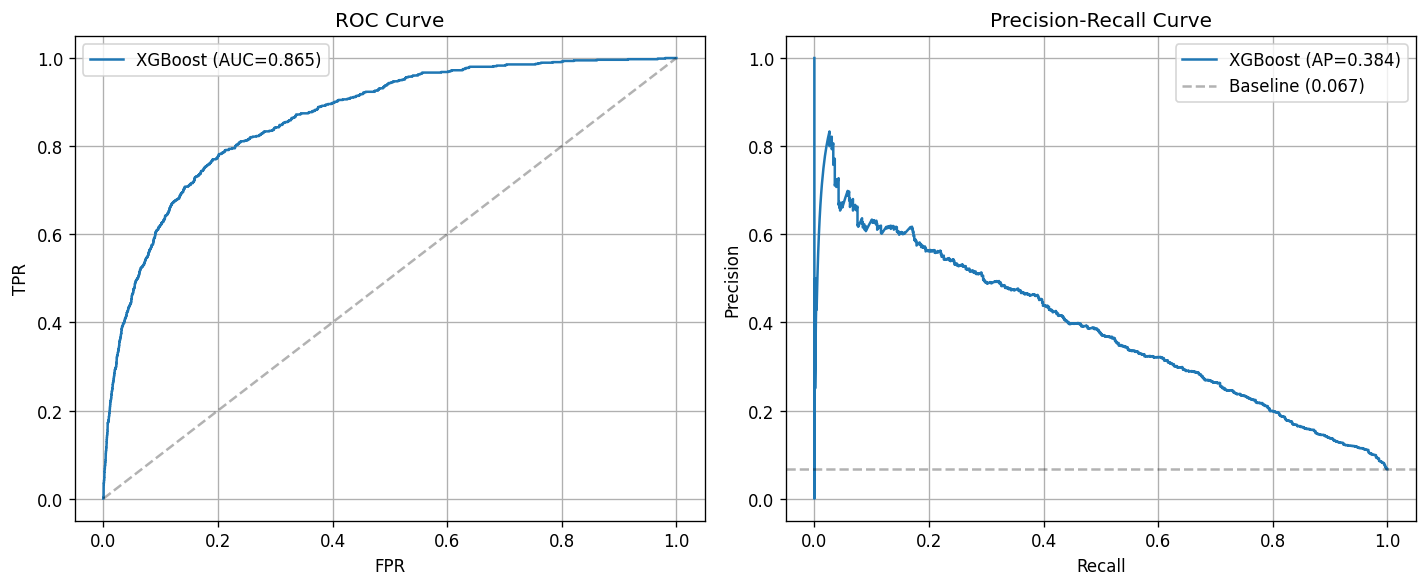

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y, probas_cv)
axes[0].plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend()

prec, rec, _ = precision_recall_curve(y, probas_cv)
axes[1].plot(rec, prec, label=f"XGBoost (AP={pr_auc:.3f})")
axes[1].axhline(y.mean(), color="k", ls="--", alpha=0.3, label=f"Baseline ({y.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

plt.tight_layout(); plt.show()

## 9. Calibration & multi-threshold evaluation (§3.4)

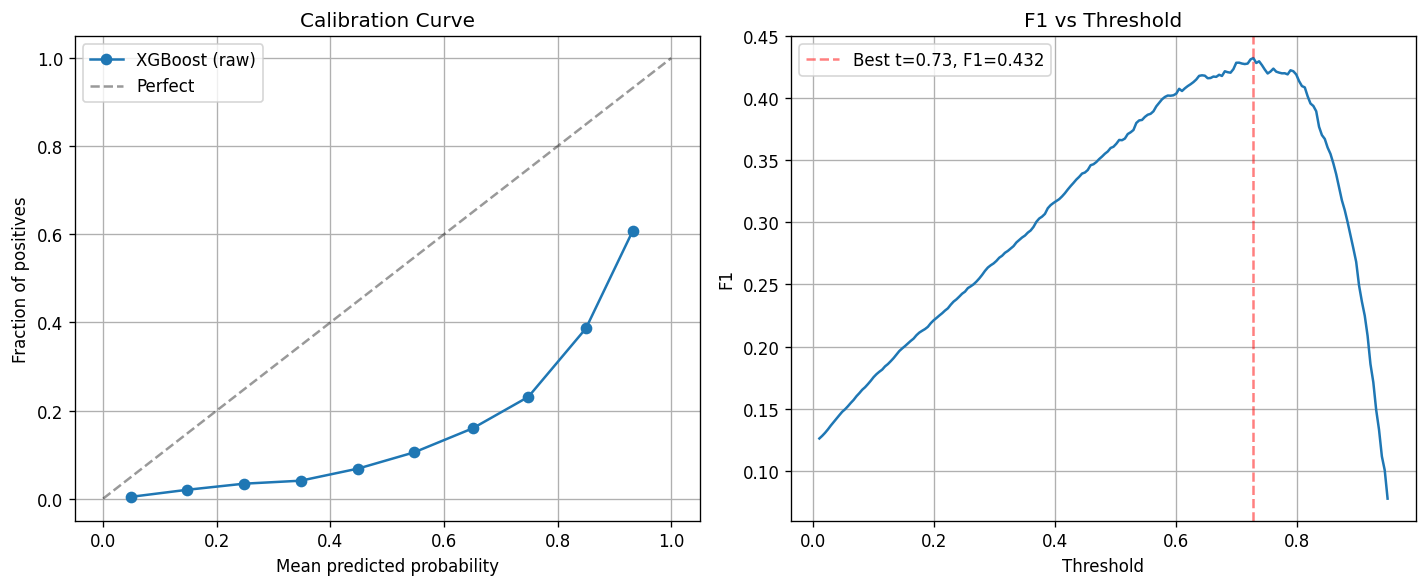


=== Multi-threshold evaluation ===
  t=0.05  Prec=0.080  Rec=0.993  F1=0.148  Flagged=9,388
  t=0.10  Prec=0.096  Rec=0.980  F1=0.175  Flagged=7,701
  t=0.15  Prec=0.111  Rec=0.960  F1=0.199  Flagged=6,534
  t=0.20  Prec=0.126  Rec=0.923  F1=0.222  Flagged=5,549
  t=0.73  Prec=0.386  Rec=0.491  F1=0.432  Flagged=964 <-- best F1
  t=0.50  Prec=0.241  Rec=0.733  F1=0.362  Flagged=2,306


In [10]:
# Calibration plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fp, mp = calibration_curve(y, probas_cv, n_bins=10, strategy="uniform")
axes[0].plot(mp, fp, marker="o", label="XGBoost (raw)")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title("Calibration Curve"); axes[0].legend()

# Multi-threshold F1
thresholds = np.linspace(0.01, 0.95, 200)
f1s = [f1_score(y, (probas_cv >= t).astype(int), zero_division=0) for t in thresholds]
best_idx = np.argmax(f1s)
best_t, best_f1 = thresholds[best_idx], f1s[best_idx]
axes[1].plot(thresholds, f1s)
axes[1].axvline(best_t, color="r", ls="--", alpha=0.5, label=f"Best t={best_t:.2f}, F1={best_f1:.3f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs Threshold"); axes[1].legend()

plt.tight_layout(); plt.show()

# Report at multiple operating points (§3.4)
print("\n=== Multi-threshold evaluation ===")
for t in [0.05, 0.10, 0.15, 0.20, best_t, 0.50]:
    preds = (probas_cv >= t).astype(int)
    tp = ((preds == 1) & (y == 1)).sum()
    fp_count = ((preds == 1) & (y == 0)).sum()
    fn = ((preds == 0) & (y == 1)).sum()
    prec_t = tp / max(tp + fp_count, 1)
    rec_t  = tp / max(tp + fn, 1)
    f1_t   = 2 * prec_t * rec_t / max(prec_t + rec_t, 1e-9)
    marker = " <-- best F1" if abs(t - best_t) < 0.01 else ""
    print(f"  t={t:.2f}  Prec={prec_t:.3f}  Rec={rec_t:.3f}  F1={f1_t:.3f}  Flagged={preds.sum():,}{marker}")

## 10. Confusion matrix (best threshold)

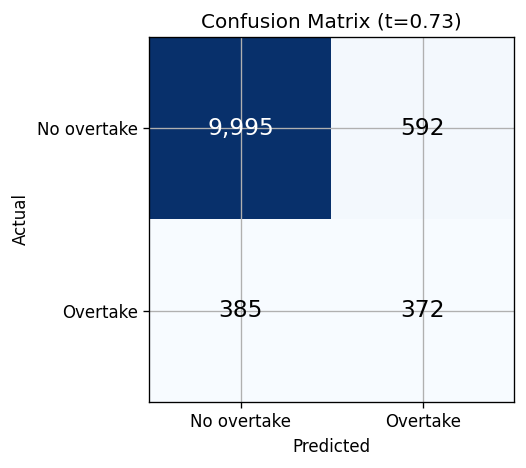

              precision    recall  f1-score   support

 No overtake       0.96      0.94      0.95     10587
    Overtake       0.39      0.49      0.43       757

    accuracy                           0.91     11344
   macro avg       0.67      0.72      0.69     11344
weighted avg       0.92      0.91      0.92     11344



In [11]:
best_preds = (probas_cv >= best_t).astype(int)
cm = confusion_matrix(y, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No overtake", "Overtake"])
ax.set_yticklabels(["No overtake", "Overtake"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (t={best_t:.2f})")
plt.tight_layout(); plt.show()

print(classification_report(y, best_preds, target_names=["No overtake", "Overtake"]))

## 11. Battle-pair level evaluation (§4.1)

For each battle pair, take the max predicted probability across laps.  
Evaluate at the pair level: "did this battle eventually result in an overtake?"

Battle-pair level evaluation (4,694 pairs):
  Positive rate: 16.13%
  ROC-AUC : 0.8816
  PR-AUC  : 0.5877


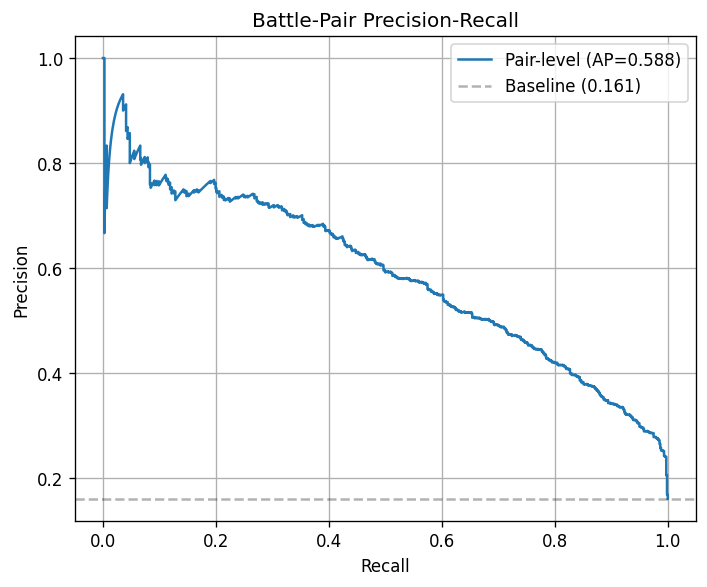

In [12]:
df_eval = df_train.copy()
df_eval["proba"] = probas_cv

pair_eval = df_eval.groupby("battle_group").agg(
    max_proba=("proba", "max"),
    mean_proba=("proba", "mean"),
    any_overtake=("overtake", "max"),
    n_laps=("lap_number", "count"),
).reset_index()

pair_y = pair_eval["any_overtake"].astype(int).values
pair_probas = pair_eval["max_proba"].values

pair_roc = roc_auc_score(pair_y, pair_probas)
pair_pr  = average_precision_score(pair_y, pair_probas)

print(f"Battle-pair level evaluation ({len(pair_eval):,} pairs):")
print(f"  Positive rate: {pair_y.mean():.2%}")
print(f"  ROC-AUC : {pair_roc:.4f}")
print(f"  PR-AUC  : {pair_pr:.4f}")

# PR curve at pair level
fig, ax = plt.subplots(figsize=(6, 5))
prec_p, rec_p, _ = precision_recall_curve(pair_y, pair_probas)
ax.plot(rec_p, prec_p, label=f"Pair-level (AP={pair_pr:.3f})")
ax.axhline(pair_y.mean(), color="k", ls="--", alpha=0.3, label=f"Baseline ({pair_y.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Battle-Pair Precision-Recall"); ax.legend()
plt.tight_layout(); plt.show()

## 12. Temporal calibration per year (§4.2)

In [13]:
df_eval["year"] = df_train["year"].values

print("Per-year calibration (CV predictions):")
print(f"{'Year':>6}  {'N':>6}  {'OT rate':>8}  {'ROC-AUC':>8}  {'PR-AUC':>8}  {'Brier':>8}")
for yr in sorted(df_eval["year"].unique()):
    mask = df_eval["year"] == yr
    y_yr = df_eval.loc[mask, "overtake"].astype(int).values
    p_yr = df_eval.loc[mask, "proba"].values
    if y_yr.sum() < 2:
        continue
    roc_yr = roc_auc_score(y_yr, p_yr)
    pr_yr  = average_precision_score(y_yr, p_yr)
    brier_yr = brier_score_loss(y_yr, p_yr)
    print(f"{yr:>6}  {mask.sum():>6,}  {y_yr.mean():>8.2%}  {roc_yr:>8.4f}  {pr_yr:>8.4f}  {brier_yr:>8.4f}")

Per-year calibration (CV predictions):
  Year       N   OT rate   ROC-AUC    PR-AUC     Brier
  2022   3,867     7.89%    0.8449    0.3843    0.1324
  2023   3,728     5.95%    0.8570    0.3092    0.1183
  2024   3,749     6.13%    0.8968    0.4733    0.1150


## 13. Track-stratified evaluation (§4.3)

In [14]:
df_eval["track_type"] = df_train["track_type"].values

print("Per-track-type evaluation (CV predictions):")
print(f"{'Type':<14} {'N':>6}  {'OT rate':>8}  {'ROC-AUC':>8}  {'PR-AUC':>8}")
for tt in sorted(df_eval["track_type"].unique()):
    mask = df_eval["track_type"] == tt
    y_tt = df_eval.loc[mask, "overtake"].astype(int).values
    p_tt = df_eval.loc[mask, "proba"].values
    if y_tt.sum() < 2:
        continue
    roc_tt = roc_auc_score(y_tt, p_tt)
    pr_tt  = average_precision_score(y_tt, p_tt)
    print(f"{tt:<14} {mask.sum():>6,}  {y_tt.mean():>8.2%}  {roc_tt:>8.4f}  {pr_tt:>8.4f}")

Per-track-type evaluation (CV predictions):
Type                N   OT rate   ROC-AUC    PR-AUC
low-speed         876     1.37%    0.7210    0.1400
street         10,468     7.12%    0.8673    0.3941


## 14. Feature importance

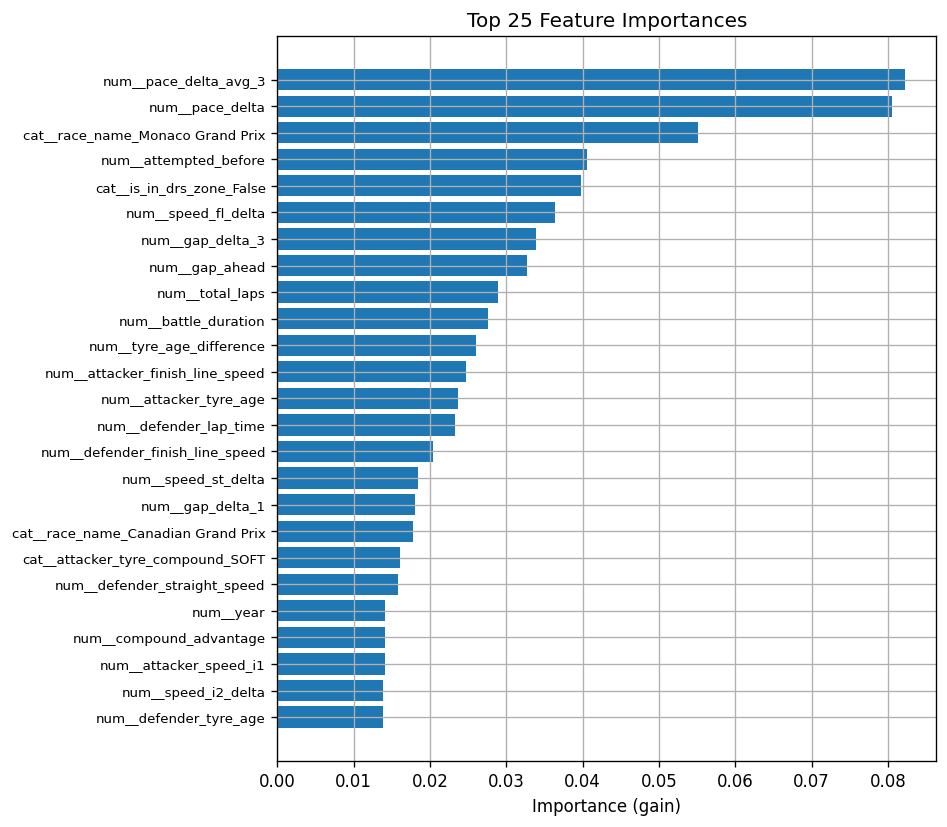

In [15]:
# Train on full training set for feature importance
fi_clf = xgb.XGBClassifier(**best_params)
fi_clf.fit(X_transformed, y)

ohe_feature_names = preprocessor.get_feature_names_out()
importances = fi_clf.feature_importances_

fi_df = pd.DataFrame({"feature": ohe_feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(len(fi_df)), fi_df["importance"].values)
ax.set_yticks(range(len(fi_df)))
ax.set_yticklabels(fi_df["feature"].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 25 Feature Importances")
plt.tight_layout(); plt.show()

## 15. Save model artefacts

In [16]:
import joblib
import json as _json
import datetime

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Retrain on full 2022-2024 with isotonic calibration
final_xgb = xgb.XGBClassifier(**best_params)
final_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_all = final_preprocessor.fit_transform(X)
final_cal = CalibratedClassifierCV(final_xgb, method="isotonic", cv=5)
final_cal.fit(X_all, y)

full_pipeline = Pipeline([
    ("preprocess", final_preprocessor),
    ("classifier", final_cal),
])

model_path = ARTIFACTS_DIR / "overtake_model_v3.pkl"
meta_path  = ARTIFACTS_DIR / "overtake_model_v3_meta.json"

joblib.dump(full_pipeline, model_path)

meta = {
    "model": "XGBoost",
    "calibration": "isotonic",
    "features": FEATURE_COLS,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "best_params": {k: v for k, v in best_params.items() if k != "n_jobs"},
    "threshold": float(best_t),
    "train_years": TRAIN_YEARS,
    "train_rows": int(len(X)),
    "overtake_rate": float(y.mean()),
    "cv_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "brier": float(brier),
    },
    "data_version": "v3",
    "ip02_improvements": [
        "actual_gap (LapStartTime)",
        "pit_stop_filter",
        "signed_tyre_age_diff",
        "gap_trend_features",
        "pace_delta",
        "speed_deltas",
        "battle_context",
        "tyre_cliff",
        "xgboost_optuna",
    ],
    "saved_at": datetime.datetime.now().isoformat(),
}
meta_path.write_text(_json.dumps(meta, indent=2))

print(f"Model saved    -> {model_path}")
print(f"Metadata saved -> {meta_path}")
print(f"Trained on     : {TRAIN_YEARS}  ({len(X):,} battles)")
print(f"Decision threshold: {best_t:.3f}")

Model saved    -> artifacts/overtake_model_v3.pkl
Metadata saved -> artifacts/overtake_model_v3_meta.json
Trained on     : [2022, 2023, 2024]  (11,344 battles)
Decision threshold: 0.728


## 16. Holdout evaluation on 2025 data

The model is now applied to the **unseen 2025 season**. No 2025 data was used for training, feature engineering thresholds, or threshold selection.

In [17]:
if X_test is not None and y_test is not None:
    probas_2025 = full_pipeline.predict_proba(X_test)[:, 1]
    preds_2025  = (probas_2025 >= best_t).astype(int)

    roc_25 = roc_auc_score(y_test, probas_2025)
    pr_25  = average_precision_score(y_test, probas_2025)
    brier_25 = brier_score_loss(y_test, probas_2025)

    print("2025 Holdout Results (per-lap)")
    print("=" * 40)
    print(f"  ROC-AUC  : {roc_25:.4f}")
    print(f"  PR-AUC   : {pr_25:.4f}")
    print(f"  Brier    : {brier_25:.4f}")
    print()
    print(classification_report(y_test, preds_2025, target_names=["No overtake", "Overtake"]))

    # Multi-threshold on holdout
    print("\n=== 2025 multi-threshold ===")
    for t in [0.05, 0.10, 0.15, 0.20, best_t, 0.50]:
        p25 = (probas_2025 >= t).astype(int)
        tp = ((p25 == 1) & (y_test == 1)).sum()
        fp_c = ((p25 == 1) & (y_test == 0)).sum()
        fn = ((p25 == 0) & (y_test == 1)).sum()
        pr_t = tp / max(tp + fp_c, 1)
        re_t = tp / max(tp + fn, 1)
        print(f"  t={t:.2f}  Prec={pr_t:.3f}  Rec={re_t:.3f}  Flagged={p25.sum():,}")

    # Battle-pair level on 2025
    df_test_eval = df_test.copy()
    df_test_eval["proba"] = probas_2025
    pair_2025 = df_test_eval.groupby("battle_group").agg(
        max_proba=("proba", "max"),
        any_overtake=("overtake", "max"),
    ).reset_index()
    pair_y25 = pair_2025["any_overtake"].astype(int).values
    pair_p25 = pair_2025["max_proba"].values

    if pair_y25.sum() > 0:
        pair_roc_25 = roc_auc_score(pair_y25, pair_p25)
        pair_pr_25  = average_precision_score(pair_y25, pair_p25)
        print(f"\n2025 Battle-pair level ({len(pair_2025):,} pairs):")
        print(f"  Positive rate: {pair_y25.mean():.2%}")
        print(f"  ROC-AUC : {pair_roc_25:.4f}")
        print(f"  PR-AUC  : {pair_pr_25:.4f}")

    # Per-race analysis
    print("\nMean predicted overtake probability by 2025 race:")
    print(
        df_test_eval.groupby("race_name")["proba"]
        .mean()
        .sort_values(ascending=False)
        .to_string()
    )
else:
    print("Skipping holdout — 2025 data not available.")

2025 Holdout Results (per-lap)
  ROC-AUC  : 0.8881
  PR-AUC   : 0.4673
  Brier    : 0.0366

              precision    recall  f1-score   support

 No overtake       0.95      1.00      0.98      4398
    Overtake       0.84      0.13      0.23       243

    accuracy                           0.95      4641
   macro avg       0.90      0.57      0.60      4641
weighted avg       0.95      0.95      0.94      4641


=== 2025 multi-threshold ===
  t=0.05  Prec=0.202  Rec=0.794  Flagged=956
  t=0.10  Prec=0.264  Rec=0.704  Flagged=647
  t=0.15  Prec=0.316  Rec=0.617  Flagged=474
  t=0.20  Prec=0.385  Rec=0.564  Flagged=356
  t=0.73  Prec=0.842  Rec=0.132  Flagged=38
  t=0.50  Prec=0.674  Rec=0.263  Flagged=95

2025 Battle-pair level (1,800 pairs):
  Positive rate: 13.50%
  ROC-AUC : 0.9102
  PR-AUC  : 0.6959

Mean predicted overtake probability by 2025 race:
race_name
Azerbaijan Grand Prix       0.085338
United States Grand Prix    0.080582
Saudi Arabian Grand Prix    0.078022
Abu Dhabi 

## 17. Comparison with v2 model

Summary table comparing v2 and v3 results.

In [18]:
v2_metrics = {
    "ROC-AUC (CV)": 0.782,
    "PR-AUC (CV)": 0.149,
    "Brier (CV)": 0.029,
    "ROC-AUC (2025)": 0.785,
    "PR-AUC (2025)": 0.200,
    "Brier (2025)": 0.035,
}

v3_cv = {"ROC-AUC (CV)": roc_auc, "PR-AUC (CV)": pr_auc, "Brier (CV)": brier}

if X_test is not None:
    v3_cv["ROC-AUC (2025)"] = roc_25
    v3_cv["PR-AUC (2025)"] = pr_25
    v3_cv["Brier (2025)"] = brier_25

comp = pd.DataFrame({"v2 (RF)": v2_metrics, "v3 (XGB)": v3_cv}).T
print("\n=== v2 vs v3 Comparison ===")
print(comp.to_string(float_format="{:.4f}".format))


=== v2 vs v3 Comparison ===
          ROC-AUC (CV)  PR-AUC (CV)  Brier (CV)  ROC-AUC (2025)  PR-AUC (2025)  Brier (2025)
v2 (RF)         0.7820       0.1490      0.0290          0.7850         0.2000        0.0350
v3 (XGB)        0.8653       0.3839      0.1220          0.8881         0.4673        0.0366
